In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem_12bit

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'This movie is absolutely pointless, one of the good esamples how Malcom McDowall never got one decent role after Clockwork Orange. This one may be one of the worst though. No story, crappy special effects, shot in 4:3/or even worse cropped on DVD, just avoid it ....'

In [5]:
print(preprocess(df.iloc[random_num]['review']))

movie absolutely pointless one good esamples malcom mcdowall never got one decent role clockwork orange one may one worst though story crappy special effect shot even worse cropped dvd avoid


In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [13]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(8, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(8, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 4)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 120, 4)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,497 (314.44 KB)

 Trainable params: 80,497 (314.44 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [15]:
"""lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)"""

'lstm_history = lstm_model.fit(\n    X_train_pad, y_train,\n    epochs=100,\n    batch_size=128,   \n    validation_split=0.2,\n    callbacks=[early_stop, reduce_lr],\n    verbose=1\n)'

In [16]:
#lstm_model.save_weights("lstm_modelo_pesado_v2.weights.h5")

In [17]:

lstm_model.load_weights("lstm_modelo_pesado_v2.weights.h5")

c:\Users\jose.sales\AppData\Local\miniconda3\envs\ilumpy\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [19]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8753 - loss: 0.3058
Test Accuracy: 0.8752999901771545


#### Acurácia de 0.80119

# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


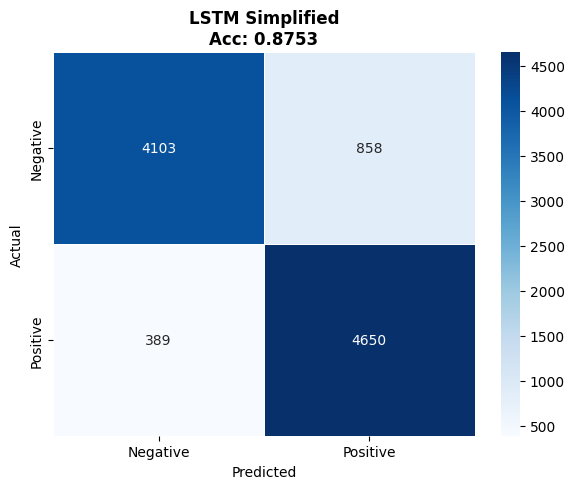

In [20]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM Simplified\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [21]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.83      0.87      4961
    Positive       0.84      0.92      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.88      0.87     10000



# Teste de Outputs


In [22]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model_v2.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_Simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Outputs salvos em layer_outputs_Simplified_model.txt


In [23]:
from functions import *

# Exportação de Pesos

In [24]:
export_weights(lstm_model, mode='lstm', output_file="../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos para 12 bits
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x000 Wx_input[0][0] = -0.416136
  addr=0x001 Wx_input[0][1] = 0.025887
  addr=0x010 Wx_input[1][0] = 0.149577
  addr=0x011 Wx_input[1][1] = -0.394139
  addr=0x008 Wh_input[0][0] = -0.005295
  addr=0x009 Wh_input[0][1] = -0.444920
  addr=0x018 Wh_input[1][0] = 0.281369
  addr=0x019 Wh_input[1][1] = -0.144929
  addr=0x200 bias_input[0] = 0.154223
  addr=0x210 bias_input[1] = 0.084396
  addr=0x080 Wx_forget[0][0] = -0.113008
  addr=0x081 Wx_forget[0][1] = 0.110063
  addr=0x090 Wx_forget[1][0] = 0.450929
  addr=0x091 Wx_forget[1][1] = -0.363480
  addr=0x088 Wh_forget[0][0] = 0.117569
  addr=0x089 Wh_forget[0][1] = 0.099637
  addr=0x098 Wh_forget[1][0] = 0.358947
  addr=0x099 Wh_forget[1][1] = -0.145330
  addr=0x280 bias_forget[0] = 1.157762
  addr=0x290 bias_forget[1] = 1.068652
  addr=0x100 Wx_candidate[0][0] = 0.373510
  addr=0x101 Wx_candidate[0][1] = -0.688837
  addr=0x110 Wx_candi

# Teste Global

In [25]:
FRAC = 24
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q24(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [26]:
def export_matrix_to_mem_12bit(matrix, result=None, ground_result=None, output_file="matrix.mem"):
    """Exporta matriz para formato Q8.24 com endereços de 12 bits"""
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            # Garante que o endereço cabe em 12 bits
            if addr > 0xFFF:
                print(f"ATENÇÃO: addr=0x{addr:04X} excede 12 bits!")
            valor = matrix[linha_idx, col_idx]
            valor_q = float_to_q(valor)
            mem[addr] = valor_q
    
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q(result) if result is not None else 0
        gt_hex = ground_result if ground_result is not None else 0
        
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            if line == 0 and result is not None:
                f.write(f"{int(addr):03x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(gt_hex) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):03x} {int(val) & 0xFFFFFFFF:08X}\n")
            line += 1
    
    print(f"Arquivo salvo: {output_file}")
    return mem

In [27]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
total = len(y_pred_lstm)
#total = 10
valores_out_embbeding = []
valores_out_lstm = []
valores_out_relu = []
valores_out_sigmoid = []

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem_12bit(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/Global Processing/dados_{i}.mem")

    valores_out_embbeding += outputs[0].reshape(-1).tolist()
    valores_out_lstm += outputs[2].reshape(-1).tolist()
    valores_out_relu += outputs[4].reshape(-1).tolist()
    valores_out_sigmoid += outputs[6].reshape(-1).tolist()

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/Global Processing/dados_0.mem
0 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/Global Processing/dados_1.mem
1 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/Global Processing/dados_2.mem
2 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/Global Processing/dados_3.mem
3 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/Global Processing/dados_4.mem
4 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24 V2/Simplified Neural Network/Global Processing/dados_5.mem
5 de 10000
1/1 ━━━━━━━━━━

KeyboardInterrupt: 